# TelecomX 2 — Predicción de Cancelación de Clientes (Churn)
> **Pipeline completo:** EDA → Preprocesamiento → Modelado → Evaluación → Conclusiones estratégicas

---

## 0. Importación de Librerías

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print(" SMOTE disponible (imbalanced-learn)")
except ImportError:
    SMOTE_AVAILABLE = False
    print("  SMOTE no disponible: se usará class_weight='balanced'")

plt.rcParams["figure.dpi"] = 130
plt.rcParams["font.family"] = "DejaVu Sans"
sns.set_theme(style="whitegrid", palette="muted")
print(" Librerías cargadas correctamente.")

 SMOTE disponible (imbalanced-learn)
 Librerías cargadas correctamente.


---
## 1. Conoce los Datos
### 1.1 Carga del Dataset JSON

In [2]:
with open("TelecomX_Data.json", "r", encoding="utf-8") as f:
    raw_data = json.load(f)

df = pd.json_normalize(raw_data)
df.columns = df.columns.str.strip()

print(f"Dimensiones originales: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print("Columnas originales:", df.columns.tolist())

# ── Renombrar columnas: eliminar prefijos customer. / phone. / internet. / account. ──
rename_map = {}
for col in df.columns:
    for prefix in ["customer.", "phone.", "internet.", "account."]:
        if col.startswith(prefix):
            new_name = col[len(prefix):]          # elimina el prefijo
            # Charges.Monthly / Charges.Total quedan como están
            rename_map[col] = new_name
            break

df.rename(columns=rename_map, inplace=True)

print(f"\n Columnas renombradas ({len(rename_map)} columnas):")
print(df.columns.tolist())
print()
df.head()

Dimensiones originales: 7,267 filas × 21 columnas
Columnas originales: ['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen', 'customer.Partner', 'customer.Dependents', 'customer.tenure', 'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService', 'internet.OnlineSecurity', 'internet.OnlineBackup', 'internet.DeviceProtection', 'internet.TechSupport', 'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract', 'account.PaperlessBilling', 'account.PaymentMethod', 'account.Charges.Monthly', 'account.Charges.Total']

 Columnas renombradas (19 columnas):
['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']



,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


### 1.2 Tipos de Datos y Estadísticas Generales

In [3]:
print("=== Tipos de datos ===")
print(df.dtypes)
print()
print("=== Estadísticas descriptivas ===")
df.describe(include="all").T

=== Tipos de datos ===
customerID           object
Churn                object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
Charges.Monthly     float64
Charges.Total        object
dtype: object

=== Estadísticas descriptivas ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7267,7267,0002-ORFBO,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Churn,7267,3,No,5174,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7267,2,Male,3675,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7267.0,NaN,NaN,NaN,0.162653,0.369074,0.0,0.0,0.0,0.0,1.0
Partner,7267,2,No,3749,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7267,2,No,5086,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7267.0,NaN,NaN,NaN,32.346498,24.571773,0.0,9.0,29.0,55.0,72.0
PhoneService,7267,2,Yes,6560,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7267,3,No,3495,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7267,3,Fiber optic,3198,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.3 Detección y Corrección de Problemas

In [4]:
# ── Valores nulos ──
print("=== Valores nulos ===")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.sum() > 0 else "Sin valores nulos detectados")

# ── Duplicados ──
dupes = df.duplicated().sum()
print(f"\n=== Filas duplicadas: {dupes} ===")

# ── Valores en blanco (strings vacíos) ──
print("\n=== Valores en blanco por columna ===")
found_blank = False
for col in df.select_dtypes("object").columns:
    blanks = (df[col].astype(str).str.strip() == "").sum()
    if blanks > 0:
        print(f"  '{col}': {blanks} valores en blanco")
        found_blank = True
if not found_blank:
    print("  Sin valores en blanco encontrados")

=== Valores nulos ===
Sin valores nulos detectados

=== Filas duplicadas: 0 ===

=== Valores en blanco por columna ===
  'Churn': 224 valores en blanco
  'Charges.Total': 11 valores en blanco


In [5]:
# ── CORRECCIONES ──

# 1) Charges.Total → numérico (puede venir como string vacío o con espacios)
df["Charges.Total"] = pd.to_numeric(df["Charges.Total"], errors="coerce")
df["Charges.Monthly"] = pd.to_numeric(df["Charges.Monthly"], errors="coerce")

# 2) Limpiar Churn de espacios y eliminar NaN
df["Churn"] = df["Churn"].astype(str).str.strip().replace("nan", np.nan)
df.dropna(subset=["Churn"], inplace=True)
df.drop_duplicates(inplace=True)

# 3) Imputar Charges.Total nulo con mediana por grupo de Churn
df["Charges.Total"] = df.groupby("Churn")["Charges.Total"].transform(
    lambda x: x.fillna(x.median()))

# 4) Estandarizar SeniorCitizen (puede venir 0/1 o "Yes"/"No")
df["SeniorCitizen"] = df["SeniorCitizen"].astype(str).map(
    {"0": "No", "1": "Yes", "No": "No", "Yes": "Yes"})

print(f" Correcciones aplicadas. Dimensiones finales: {df.shape}")
print("Columnas disponibles:", df.columns.tolist())
print("\nValores únicos de Churn:         ", df["Churn"].unique())
print("Valores únicos de SeniorCitizen: ", df["SeniorCitizen"].unique())
print("Nulos en Charges.Total:          ", df["Charges.Total"].isnull().sum())
print("Nulos en Charges.Monthly:        ", df["Charges.Monthly"].isnull().sum())

 Correcciones aplicadas. Dimensiones finales: (7267, 21)
Columnas disponibles: ['customerID', 'Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total']

Valores únicos de Churn:          ['No' 'Yes' '']
Valores únicos de SeniorCitizen:  ['No' 'Yes']
Nulos en Charges.Total:           0
Nulos en Charges.Monthly:         0


### 1.4 Creación de la Columna `Cuentas_Diarias`

In [6]:
# Valor diario ≈ facturación mensual / 30 días
df["Cuentas_Diarias"] = (df["Charges.Monthly"] / 30).round(4)

print("Columna 'Cuentas_Diarias' creada.")
df[["Charges.Monthly", "Charges.Total", "Cuentas_Diarias"]].describe()

Columna 'Cuentas_Diarias' creada.


,Charges.Monthly,Charges.Total,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000
mean,64.720098,2279.730487,2.157337
std,30.129572,2267.033944,1.004319
min,18.250000,18.800000,0.608300
25%,35.425000,401.400000,1.180850
50%,70.300000,1394.550000,2.343300
75%,89.875000,3778.525000,2.995850
max,118.750000,8684.800000,3.958300


---
## 2. Preparación de los Datos
### 2.1 Eliminación de Columnas Irrelevantes

In [7]:
# customerID: identificador único, no tiene poder predictivo
df.drop(columns=["customerID"], inplace=True, errors="ignore")
print("Columnas disponibles tras limpieza:")
print(df.columns.tolist())

Columnas disponibles tras limpieza:
['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Charges.Monthly', 'Charges.Total', 'Cuentas_Diarias']


### 2.2 Encoding de Variables Categóricas
Usamos `pd.get_dummies` (One-Hot Encoding) para las columnas con más de 2 categorías
y codificación binaria manual para las de tipo Sí/No.

In [8]:
# ── Inspección previa: ver valores únicos de columnas clave ──
print("=== Valores únicos antes del encoding ===")
for col in ["Churn", "gender", "Partner", "Dependents", "PhoneService",
            "PaperlessBilling", "SeniorCitizen"]:
    if col in df.columns:
        print(f"  {col:20s}: {sorted(df[col].dropna().astype(str).unique().tolist())}")

# ── Variable objetivo: Churn ──
# Normalizar a minúsculas para capturar variantes ("Yes","yes","YES", etc.)
df["Churn"] = (
    df["Churn"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({"yes": 1, "no": 0, "1": 1, "0": 0})
)
# Eliminar filas donde Churn sigue siendo NaN tras el mapeo
n_before = len(df)
df.dropna(subset=["Churn"], inplace=True)
df["Churn"] = df["Churn"].astype(int)
print(f"\nChurn mapeado. Filas eliminadas por Churn inválido: {n_before - len(df)}")
print(f"Distribución Churn: {df['Churn'].value_counts().to_dict()}")

# ── Variables binarias Yes/No y género ──
binary_cols = ["gender", "Partner", "Dependents", "PhoneService",
               "PaperlessBilling", "SeniorCitizen"]

binary_map = {
    "yes": 1, "no": 0,
    "male": 1, "female": 0,
    "1": 1, "0": 0
}

for col in binary_cols:
    if col not in df.columns:
        continue
    # Normalizar a minúsculas → mapear → rellenar NaN con moda
    mapped = df[col].astype(str).str.strip().str.lower().map(binary_map)
    nan_count = mapped.isnull().sum()
    if nan_count > 0:
        mode_val = mapped.mode()[0]
        print(f"  '{col}': {nan_count} valores no reconocidos → imputados con moda ({int(mode_val)})")
        mapped = mapped.fillna(mode_val)
    df[col] = mapped.astype(int)

# ── Variables con múltiples categorías → One-Hot Encoding ──
multi_cols = ["MultipleLines", "InternetService", "OnlineSecurity",
              "OnlineBackup", "DeviceProtection", "TechSupport",
              "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"]
multi_cols = [c for c in multi_cols if c in df.columns]

df = pd.get_dummies(df, columns=multi_cols, drop_first=False)

# Convertir bool → int
bool_cols = df.select_dtypes(include="bool").columns
df[bool_cols] = df[bool_cols].astype(int)

print(f"\n Encoding completado. Dataset: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print("Tipos de datos restantes con object:")
obj_remaining = df.select_dtypes("object").columns.tolist()
print(obj_remaining if obj_remaining else "  Ninguno ")
df.head(3)

=== Valores únicos antes del encoding ===
  Churn               : ['', 'No', 'Yes']
  gender              : ['Female', 'Male']
  Partner             : ['No', 'Yes']
  Dependents          : ['No', 'Yes']
  PhoneService        : ['No', 'Yes']
  PaperlessBilling    : ['No', 'Yes']
  SeniorCitizen       : ['No', 'Yes']

Churn mapeado. Filas eliminadas por Churn inválido: 224
Distribución Churn: {0: 5174, 1: 1869}

 Encoding completado. Dataset: 7,043 filas × 42 columnas
Tipos de datos restantes con object:
  Ninguno 


,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,1,1,9,1,1,65.6,593.30,...,1,0,0,0,1,0,0,0,0,1
1,0,1,0,0,0,9,1,0,59.9,542.40,...,0,0,1,1,0,0,0,0,0,1
2,1,1,0,0,0,4,1,1,73.9,280.85,...,1,0,0,1,0,0,0,0,1,0


### 2.3 Verificación de la Proporción de Cancelación (Churn)

  Categoría  Cantidad  Porcentaje (%)
 Activo (0)      5174           73.46
Canceló (1)      1869           26.54


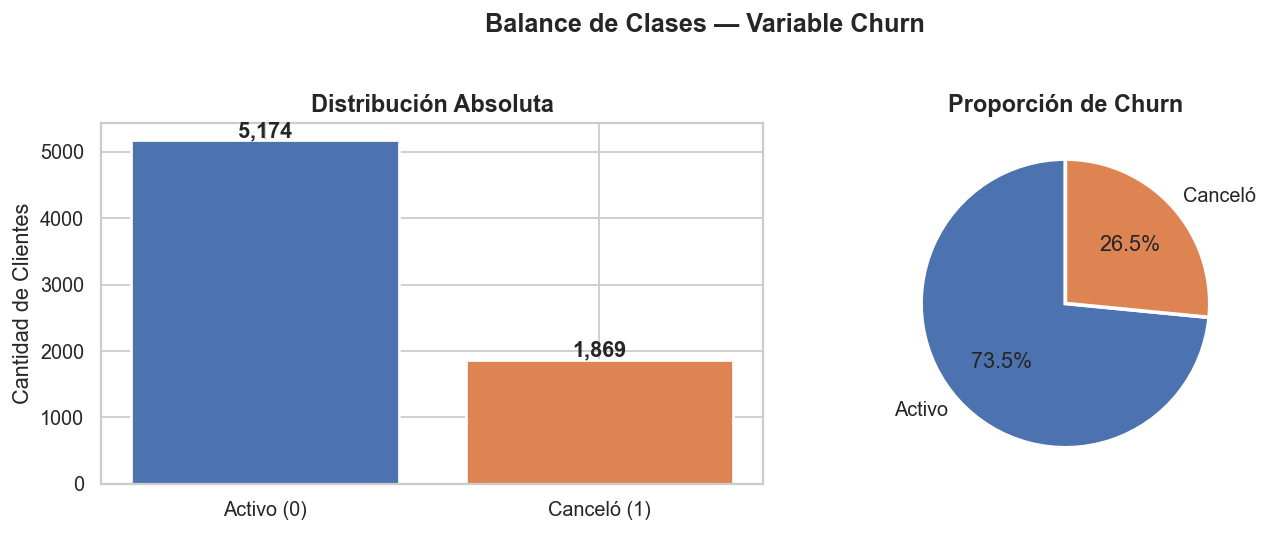


  Ratio de desbalanceo aprox.: 2.8:1
→ Se aplicará técnica de balanceo antes del entrenamiento.


In [ ]:
churn_counts = df["Churn"].value_counts()
churn_pct    = df["Churn"].value_counts(normalize=True) * 100

summary_churn = pd.DataFrame({
    "Categoría": ["Activo (0)", "Canceló (1)"],
    "Cantidad": churn_counts.values,
    "Porcentaje (%)": churn_pct.values.round(2)
})
print(summary_churn.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Barras
axes[0].bar(["Activo (0)", "Canceló (1)"], churn_counts,
            color=["#4C72B0", "#DD8452"], edgecolor="white", linewidth=1.5)
axes[0].set_title("Distribución Absoluta", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Cantidad de Clientes")
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 50, f"{v:,}", ha="center", fontweight="bold")

# Pie
axes[1].pie(churn_counts, labels=["Activo", "Canceló"],
            autopct="%1.1f%%", colors=["#4C72B0", "#DD8452"],
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Proporción de Churn", fontsize=13, fontweight="bold")

plt.suptitle("Balance de Clases — Variable Churn", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

ratio = churn_counts.iloc[0] / churn_counts.iloc[1]
print(f"\n  Ratio de desbalanceo aprox.: {ratio:.1f}:1")
print("→ Se aplicará técnica de balanceo antes del entrenamiento.")

### 2.4 Balanceo de Clases
Con ~73% Activos vs ~27% Cancelaciones, existe un desbalanceo moderado.
- Si **imbalanced-learn** está disponible: se aplica **SMOTE** (oversampling sintético).
- Si no: se usa `class_weight='balanced'` en los clasificadores.

In [10]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

# División 80/20 estratificada
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train: {X_train_raw.shape[0]:,} | Test: {X_test_raw.shape[0]:,}")
print(f"Tasa Churn Train: {y_train.mean():.2%}")
print(f"Tasa Churn Test : {y_test.mean():.2%}")

if SMOTE_AVAILABLE:
    sm = SMOTE(random_state=42)
    X_train_bal, y_train_bal = sm.fit_resample(X_train_raw, y_train)
    print(f"\nSMOTE aplicado.")
    print(f"   Tamaño post-balanceo: {X_train_bal.shape[0]:,}")
    vc = pd.Series(y_train_bal).value_counts()
    print(f"   Activos: {vc[0]:,} | Cancelaron: {vc[1]:,}")
else:
    X_train_bal, y_train_bal = X_train_raw.copy(), y_train.copy()
    print("\n→ Usando class_weight='balanced' en los modelos.")

Train: 5,634 | Test: 1,409
Tasa Churn Train: 26.54%
Tasa Churn Test : 26.54%

SMOTE aplicado.
   Tamaño post-balanceo: 8,278
   Activos: 4,139 | Cancelaron: 4,139


### 2.5 Normalización / Estandarización
- **Regresión Logística**: sensible a la escala → se aplica `StandardScaler`.
- **Random Forest / Gradient Boosting**: basados en árboles → no requieren normalización.

In [11]:
num_cols = ["tenure", "Charges.Monthly", "Charges.Total", "Cuentas_Diarias"]
num_cols = [c for c in num_cols if c in X_train_bal.columns]

scaler = StandardScaler()
X_train_scaled = X_train_bal.copy()
X_test_scaled  = X_test_raw.copy()

X_train_scaled[num_cols] = scaler.fit_transform(X_train_bal[num_cols])
X_test_scaled[num_cols]  = scaler.transform(X_test_raw[num_cols])

print(" StandardScaler aplicado a columnas continuas:")
print(X_train_scaled[num_cols].describe().T[["mean", "std"]].round(4))

 StandardScaler aplicado a columnas continuas:
                 mean     std
tenure            0.0  1.0001
Charges.Monthly  -0.0  1.0001
Charges.Total    -0.0  1.0001
Cuentas_Diarias  -0.0  1.0001


---
## 3. Correlación y Selección de Variables
### 3.1 Matriz de Correlación

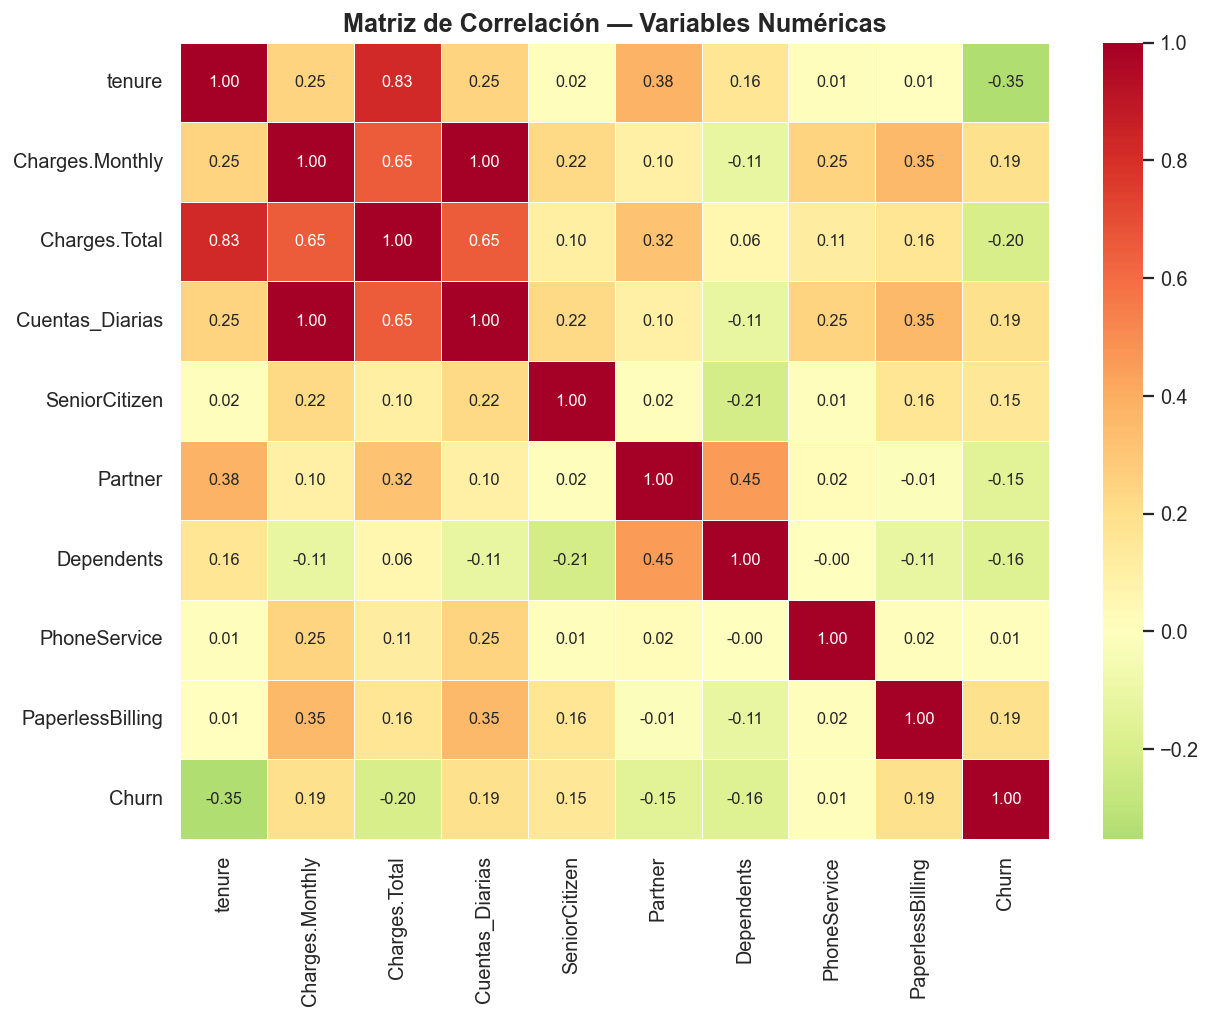


=== Correlación con Churn (ordenada por magnitud) ===
tenure             -0.3522
Charges.Total      -0.1992
Charges.Monthly     0.1934
Cuentas_Diarias     0.1934
PaperlessBilling    0.1918
Dependents         -0.1642
SeniorCitizen       0.1509
Partner            -0.1504
PhoneService        0.0119
Name: Churn, dtype: float64


In [ ]:
core_num = ["tenure", "Charges.Monthly", "Charges.Total", "Cuentas_Diarias",
            "SeniorCitizen", "Partner", "Dependents", "PhoneService",
            "PaperlessBilling", "Churn"]
core_num = [c for c in core_num if c in df.columns]

corr = df[core_num].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("Matriz de Correlación — Variables Numéricas",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n=== Correlación con Churn (ordenada por magnitud) ===")
corr_churn = corr["Churn"].drop("Churn").sort_values(key=abs, ascending=False)
print(corr_churn.round(4))

### 3.2 Análisis Dirigido: Variables Clave vs Churn

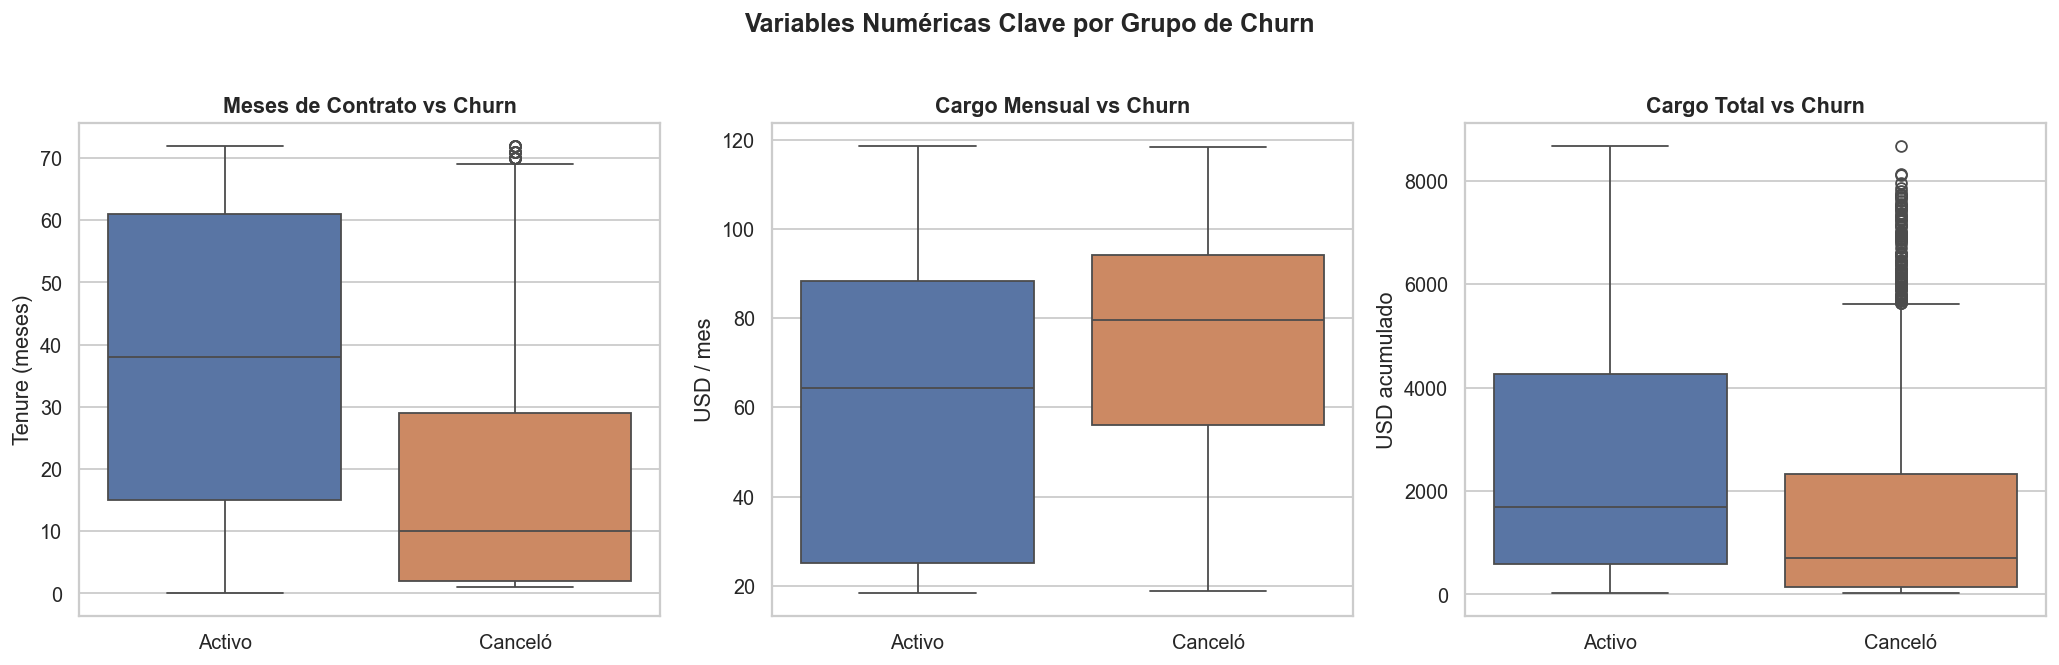

In [13]:
df_plot = df[["tenure", "Charges.Monthly", "Charges.Total", "Churn"]].copy()
df_plot["Churn_label"] = df_plot["Churn"].map({0: "Activo", 1: "Canceló"})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Tenure
sns.boxplot(data=df_plot, x="Churn_label", y="tenure",
            palette=["#4C72B0", "#DD8452"], ax=axes[0])
axes[0].set_title("Meses de Contrato vs Churn", fontweight="bold")
axes[0].set_xlabel(""); axes[0].set_ylabel("Tenure (meses)")

# Cargo Mensual
sns.boxplot(data=df_plot, x="Churn_label", y="Charges.Monthly",
            palette=["#4C72B0", "#DD8452"], ax=axes[1])
axes[1].set_title("Cargo Mensual vs Churn", fontweight="bold")
axes[1].set_xlabel(""); axes[1].set_ylabel("USD / mes")

# Cargo Total
sns.boxplot(data=df_plot, x="Churn_label", y="Charges.Total",
            palette=["#4C72B0", "#DD8452"], ax=axes[2])
axes[2].set_title("Cargo Total vs Churn", fontweight="bold")
axes[2].set_xlabel(""); axes[2].set_ylabel("USD acumulado")

plt.suptitle("Variables Numéricas Clave por Grupo de Churn",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

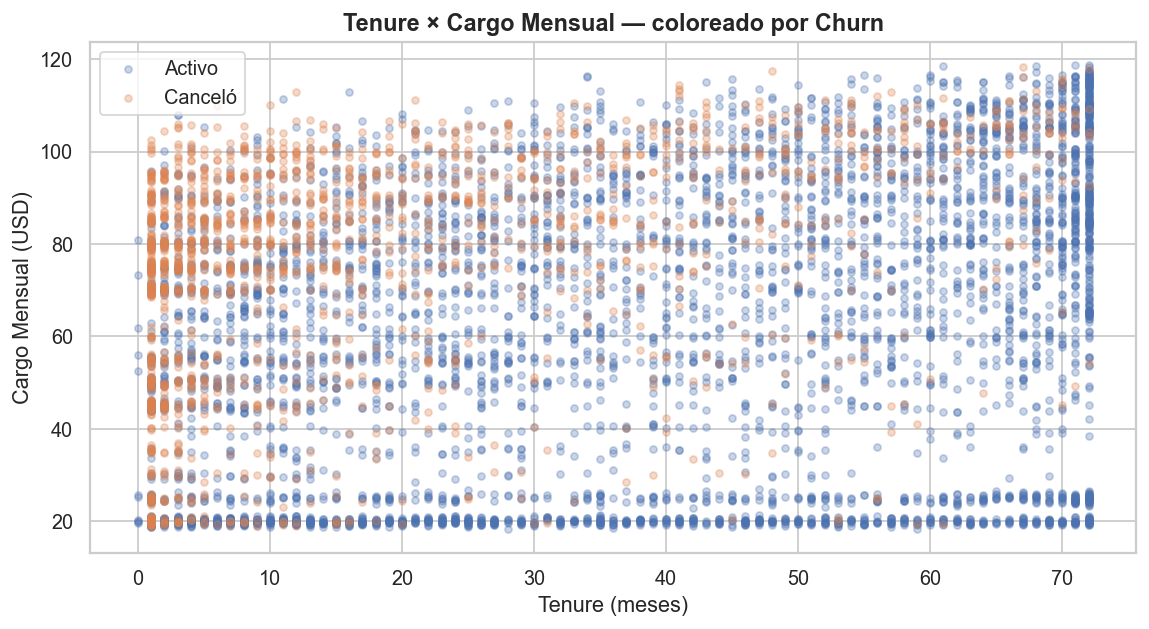

In [14]:
# Scatter: Tenure × Cargo Mensual, coloreado por Churn
fig, ax = plt.subplots(figsize=(9, 5))
for label, color, lbl in zip([0,1], ["#4C72B0","#DD8452"], ["Activo","Canceló"]):
    sub = df_plot[df_plot["Churn"] == label]
    ax.scatter(sub["tenure"], sub["Charges.Monthly"],
               c=color, alpha=0.3, s=15, label=lbl)
ax.set_xlabel("Tenure (meses)"); ax.set_ylabel("Cargo Mensual (USD)")
ax.set_title("Tenure × Cargo Mensual — coloreado por Churn",
             fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

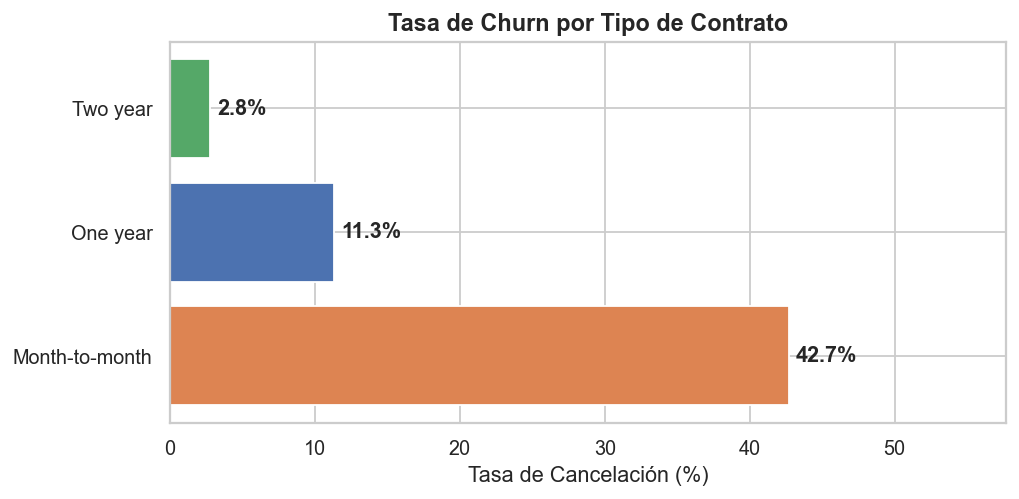

      Contrato  Tasa Churn (%)
Month-to-month            42.7
      One year            11.3
      Two year             2.8


In [15]:
# Tasa de Churn por Tipo de Contrato
contract_cols = [c for c in df.columns if c.startswith("Contract_")]
if contract_cols:
    ct_churn = []
    for col in contract_cols:
        name = col.replace("Contract_", "")
        rate = df[df[col] == 1]["Churn"].mean() * 100
        ct_churn.append({"Contrato": name, "Tasa Churn (%)": round(rate, 1)})
    ct_df = pd.DataFrame(ct_churn).sort_values("Tasa Churn (%)", ascending=False)

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(ct_df["Contrato"], ct_df["Tasa Churn (%)"],
                   color=["#DD8452", "#4C72B0", "#55A868"])
    for bar, val in zip(bars, ct_df["Tasa Churn (%)"]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f"{val}%", va="center", fontweight="bold")
    ax.set_xlabel("Tasa de Cancelación (%)")
    ax.set_title("Tasa de Churn por Tipo de Contrato",
                 fontsize=13, fontweight="bold")
    ax.set_xlim(0, max(ct_df["Tasa Churn (%)"]) + 15)
    plt.tight_layout()
    plt.show()
    print(ct_df.to_string(index=False))

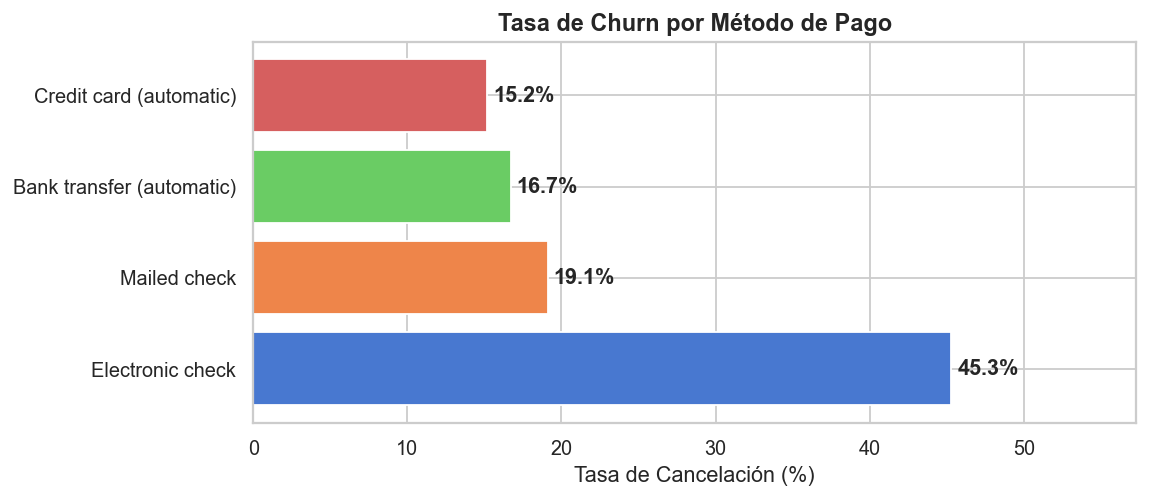

In [16]:
# Tasa de Churn por método de pago
payment_cols = [c for c in df.columns if c.startswith("PaymentMethod_")]
if payment_cols:
    pm_churn = []
    for col in payment_cols:
        name = col.replace("PaymentMethod_", "").replace("_", " ")
        rate = df[df[col] == 1]["Churn"].mean() * 100
        pm_churn.append({"Método de Pago": name, "Tasa Churn (%)": round(rate, 1)})
    pm_df = pd.DataFrame(pm_churn).sort_values("Tasa Churn (%)", ascending=False)

    fig, ax = plt.subplots(figsize=(9, 4))
    palette = sns.color_palette("muted", len(pm_df))
    ax.barh(pm_df["Método de Pago"], pm_df["Tasa Churn (%)"], color=palette)
    for i, val in enumerate(pm_df["Tasa Churn (%)"]):
        ax.text(val + 0.4, i, f"{val}%", va="center", fontweight="bold")
    ax.set_xlabel("Tasa de Cancelación (%)")
    ax.set_title("Tasa de Churn por Método de Pago",
                 fontsize=13, fontweight="bold")
    ax.set_xlim(0, max(pm_df["Tasa Churn (%)"]) + 12)
    plt.tight_layout()
    plt.show()

---
## 4. Modelado Predictivo
### 4.1 División Train / Test  (ya realizada en sección 2.4)

In [17]:
print("Resumen de conjuntos:")
print(f"  X_train (balanceado): {X_train_bal.shape}")
print(f"  X_test  (original) : {X_test_raw.shape}")
print(f"  Features            : {X_train_bal.shape[1]}")
print(f"  Churn rate Train    : {y_train_bal.mean():.2%}")
print(f"  Churn rate Test     : {y_test.mean():.2%}")

Resumen de conjuntos:
  X_train (balanceado): (8278, 41)
  X_test  (original) : (1409, 41)
  Features            : 41
  Churn rate Train    : 50.00%
  Churn rate Test     : 26.54%


### 4.2 Entrenamiento de Modelos
Entrenamos 3 modelos con diferentes enfoques:

| Modelo | Normalización | Justificación |
|--------|:---:|---|
| **Regresión Logística** | Sí | Sensible a la escala; coeficientes interpretables |
| **Random Forest** |  No | Basado en árboles; robusto sin escalar |
| **Gradient Boosting** |  No | Ensemble iterativo; mejor manejo de patrones complejos |

In [18]:
cw = "balanced" if not SMOTE_AVAILABLE else None

# ── Modelo 1: Regresión Logística ──────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42,
                        class_weight=cw, solver="lbfgs", C=1.0)
lr.fit(X_train_scaled, y_train_bal)
print(" Regresión Logística entrenada.")

# ── Modelo 2: Random Forest ────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=None,
                             random_state=42, n_jobs=-1, class_weight=cw)
rf.fit(X_train_bal, y_train_bal)
print(" Random Forest entrenado.")

# ── Modelo 3: Gradient Boosting ────────────────────────────────────────
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                 max_depth=4, random_state=42)
gb.fit(X_train_bal, y_train_bal)
print(" Gradient Boosting entrenado.")

 Regresión Logística entrenada.
 Random Forest entrenado.
 Gradient Boosting entrenado.


### 4.3 Evaluación de los Modelos

In [19]:
def evaluar_modelo(nombre, modelo, X_tr, X_te, y_tr, y_te):
    y_pred = modelo.predict(X_te)
    y_prob = modelo.predict_proba(X_te)[:, 1]

    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)

    cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_f1 = cross_val_score(modelo, X_tr, y_tr, cv=cv, scoring="f1").mean()

    print(f"{'='*55}")
    print(f" {nombre}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precisión : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"  ROC-AUC   : {auc:.4f}")
    print(f"  CV-F1 (5k): {cv_f1:.4f}  ← gap vs F1: {abs(cv_f1-f1):.4f}")
    print()
    print(classification_report(y_te, y_pred, target_names=["Activo","Canceló"]))

    return dict(Modelo=nombre, Accuracy=acc, Precision=prec,
                Recall=rec, F1=f1, ROC_AUC=auc, CV_F1=cv_f1,
                y_pred=y_pred, y_prob=y_prob)

res_lr = evaluar_modelo("Regresión Logística", lr, X_train_scaled, X_test_scaled, y_train_bal, y_test)
res_rf = evaluar_modelo("Random Forest",       rf, X_train_bal,    X_test_raw,    y_train_bal, y_test)
res_gb = evaluar_modelo("Gradient Boosting",   gb, X_train_bal,    X_test_raw,    y_train_bal, y_test)

 Regresión Logística
  Accuracy  : 0.7807
  Precisión : 0.5844
  Recall    : 0.6016
  F1-Score  : 0.5929
  ROC-AUC   : 0.8377
  CV-F1 (5k): 0.8489  ← gap vs F1: 0.2560

              precision    recall  f1-score   support

      Activo       0.85      0.85      0.85      1035
     Canceló       0.58      0.60      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

 Random Forest
  Accuracy  : 0.7871
  Precisión : 0.6057
  Recall    : 0.5668
  F1-Score  : 0.5856
  ROC-AUC   : 0.8248
  CV-F1 (5k): 0.8504  ← gap vs F1: 0.2648

              precision    recall  f1-score   support

      Activo       0.85      0.87      0.86      1035
     Canceló       0.61      0.57      0.59       374

    accuracy                           0.79      1409
   macro avg       0.73      0.72      0.72      1409
weighted avg       0.78      0.79      0.78      1409

 Gradient Boos

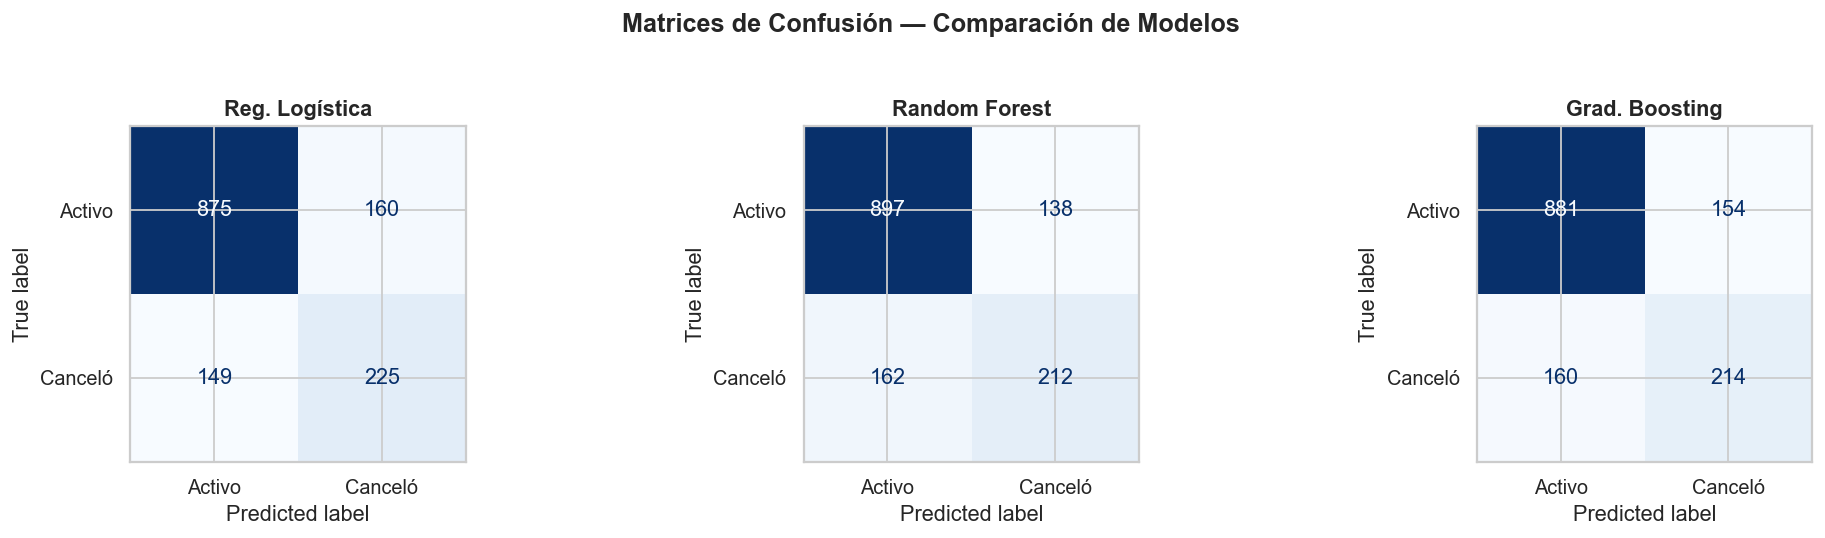

In [20]:
# ── Matrices de Confusión ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
modelos_res = [("Reg. Logística", res_lr), ("Random Forest", res_rf), ("Grad. Boosting", res_gb)]

for ax, (nombre, res) in zip(axes, modelos_res):
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=["Activo", "Canceló"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(nombre, fontsize=12, fontweight="bold")

plt.suptitle("Matrices de Confusión — Comparación de Modelos",
             fontsize=14, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()

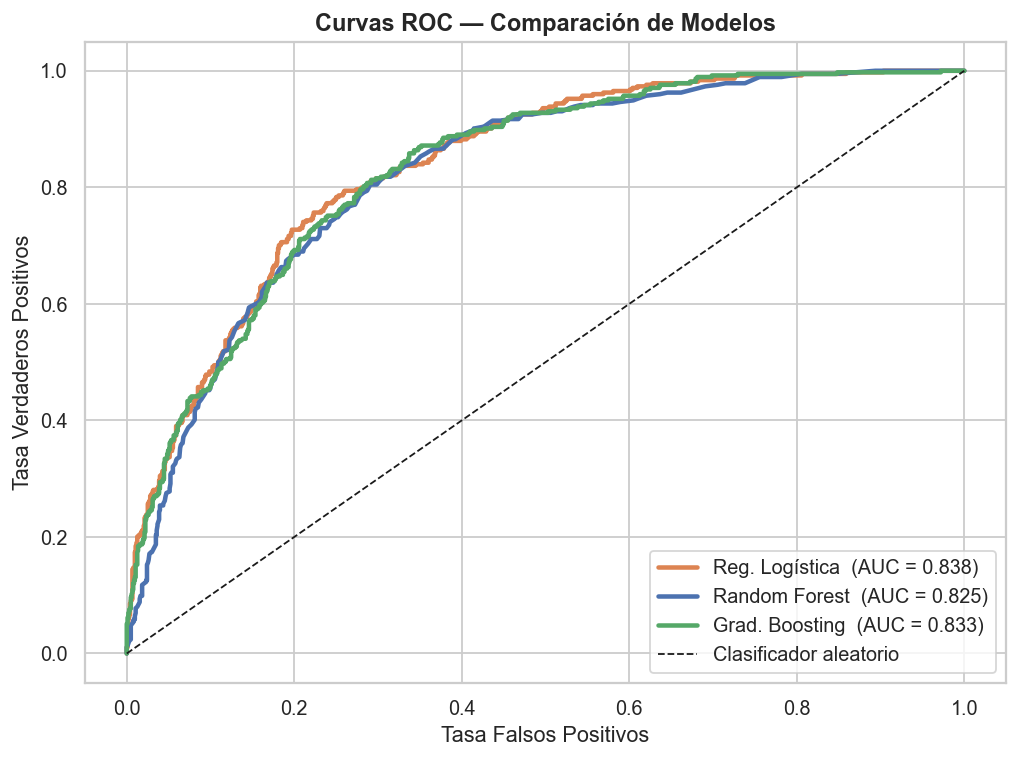

In [21]:
# ── Curvas ROC ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
palette_roc = ["#DD8452", "#4C72B0", "#55A868"]
labels_roc  = ["Reg. Logística", "Random Forest", "Grad. Boosting"]

for res, color, label in zip([res_lr, res_rf, res_gb], palette_roc, labels_roc):
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax.plot(fpr, tpr, color=color, lw=2.5,
            label=f"{label}  (AUC = {res['ROC_AUC']:.3f})")

ax.plot([0,1],[0,1], "k--", lw=1, label="Clasificador aleatorio")
ax.set_xlabel("Tasa Falsos Positivos", fontsize=12)
ax.set_ylabel("Tasa Verdaderos Positivos", fontsize=12)
ax.set_title("Curvas ROC — Comparación de Modelos", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [22]:
# ── Tabla Resumen Comparativa ─────────────────────────────────────────
summary = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ("y_pred", "y_prob")}
    for r in [res_lr, res_rf, res_gb]
]).set_index("Modelo").round(4)

print("\n=== Resumen Comparativo de Modelos ===")
print(summary[["Accuracy","Precision","Recall","F1","ROC_AUC","CV_F1"]].to_string())

best = summary["F1"].idxmax()
print(f"\n Mejor modelo por F1-Score : {best}")
print(f"   F1-Score         : {summary.loc[best, 'F1']:.4f}")
print(f"   ROC-AUC          : {summary.loc[best, 'ROC_AUC']:.4f}")
print(f"   Gap CV-F1 vs F1  : {abs(summary.loc[best,'CV_F1'] - summary.loc[best,'F1']):.4f}")


=== Resumen Comparativo de Modelos ===
                     Accuracy  Precision  Recall      F1  ROC_AUC   CV_F1
Modelo                                                                   
Regresión Logística    0.7807     0.5844  0.6016  0.5929   0.8377  0.8489
Random Forest          0.7871     0.6057  0.5668  0.5856   0.8248  0.8504
Gradient Boosting      0.7771     0.5815  0.5722  0.5768   0.8326  0.8552

 Mejor modelo por F1-Score : Regresión Logística
   F1-Score         : 0.5929
   ROC-AUC          : 0.8377
   Gap CV-F1 vs F1  : 0.2560


---
## 5. Interpretación y Conclusiones
### 5.1 Importancia de Variables
#### 5.1.1 Regresión Logística — Coeficientes

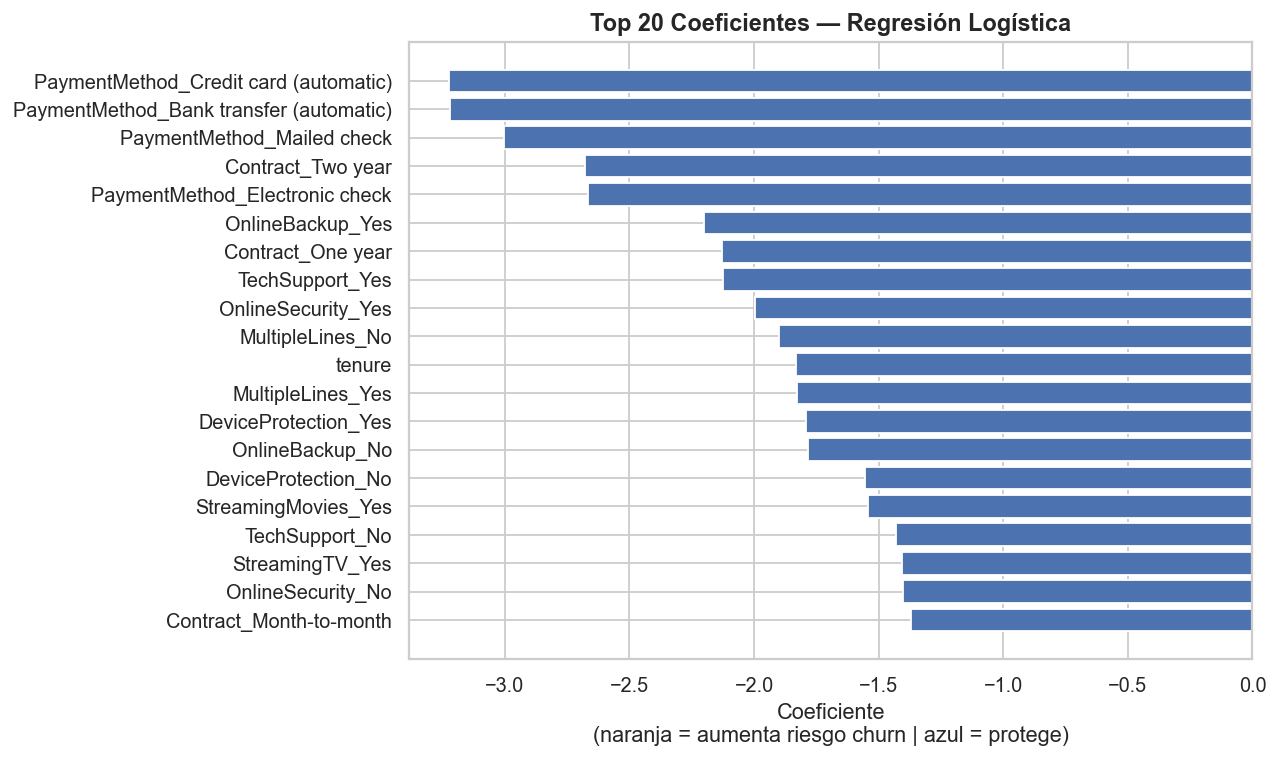

                               Variable  Coeficiente
  PaymentMethod_Credit card (automatic)    -3.223564
PaymentMethod_Bank transfer (automatic)    -3.221588
             PaymentMethod_Mailed check    -3.005547
                      Contract_Two year    -2.676823
         PaymentMethod_Electronic check    -2.665214
                       OnlineBackup_Yes    -2.202003
                      Contract_One year    -2.127891
                        TechSupport_Yes    -2.122821
                     OnlineSecurity_Yes    -1.996740
                       MultipleLines_No    -1.898174
                                 tenure    -1.830043
                      MultipleLines_Yes    -1.826035
                   DeviceProtection_Yes    -1.790345
                        OnlineBackup_No    -1.783733
                    DeviceProtection_No    -1.553427
                    StreamingMovies_Yes    -1.540925
                         TechSupport_No    -1.429912
                        StreamingTV_Yes    -1.

In [23]:
coef_df = pd.DataFrame({
    "Variable": X_train_scaled.columns,
    "Coeficiente": lr.coef_[0]
}).assign(abs_coef=lambda d: d["Coeficiente"].abs()
).sort_values("abs_coef", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ["#DD8452" if c > 0 else "#4C72B0" for c in coef_df["Coeficiente"]]
ax.barh(coef_df["Variable"], coef_df["Coeficiente"], color=colors_bar)
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Top 20 Coeficientes — Regresión Logística",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Coeficiente\n(naranja = aumenta riesgo churn | azul = protege)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
print(coef_df[["Variable","Coeficiente"]].to_string(index=False))

#### 5.1.2 Random Forest — Feature Importance

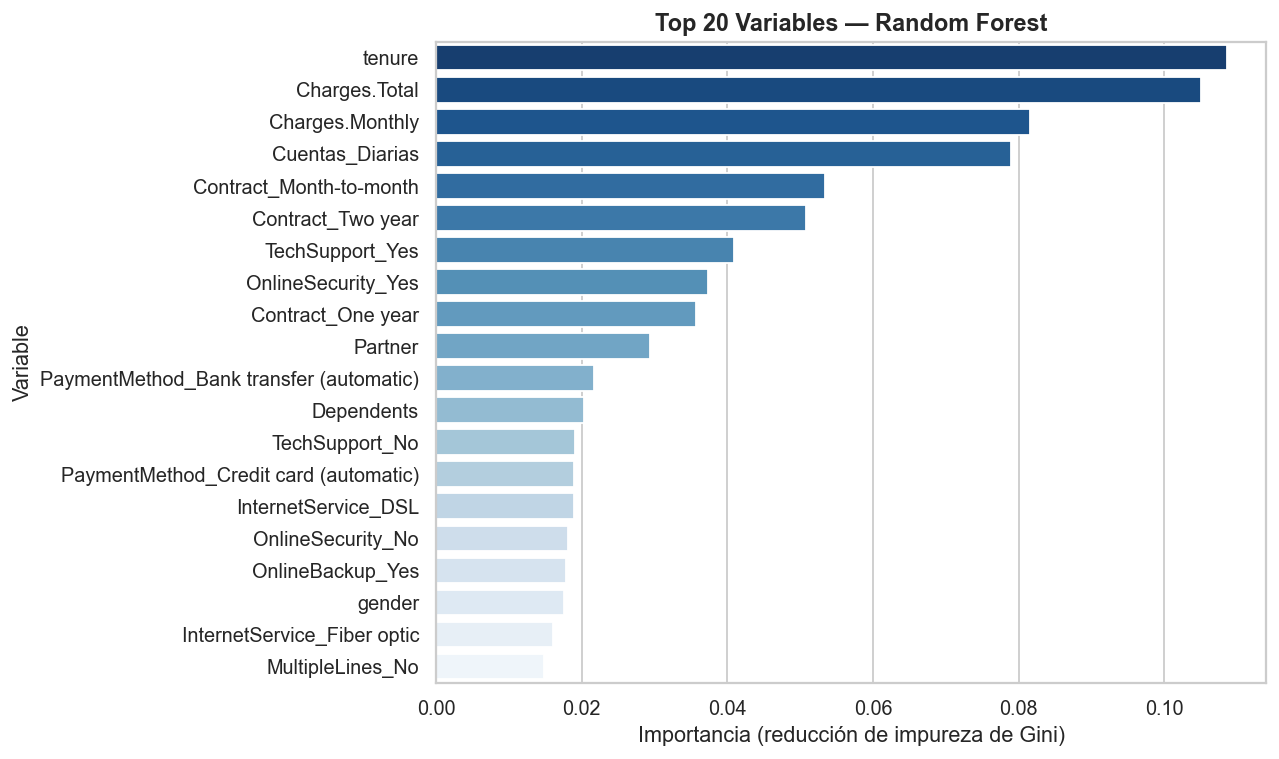

In [24]:
fi_df = pd.DataFrame({
    "Variable": X_train_bal.columns,
    "Importancia": rf.feature_importances_
}).sort_values("Importancia", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=fi_df, x="Importancia", y="Variable", palette="Blues_r", ax=ax)
ax.set_title("Top 20 Variables — Random Forest", fontsize=13, fontweight="bold")
ax.set_xlabel("Importancia (reducción de impureza de Gini)")
plt.tight_layout()
plt.show()

#### 5.1.3 Gradient Boosting — Feature Importance

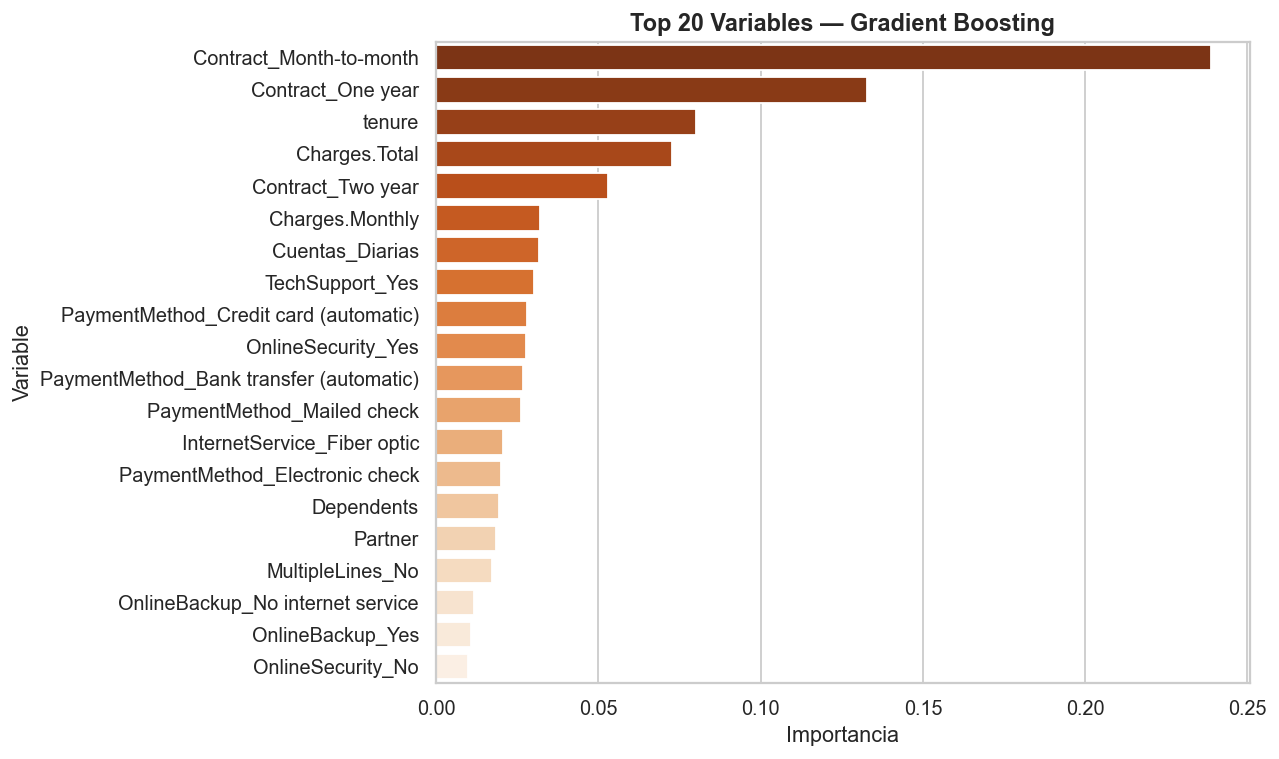

In [25]:
fi_gb = pd.DataFrame({
    "Variable": X_train_bal.columns,
    "Importancia": gb.feature_importances_
}).sort_values("Importancia", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=fi_gb, x="Importancia", y="Variable", palette="Oranges_r", ax=ax)
ax.set_title("Top 20 Variables — Gradient Boosting", fontsize=13, fontweight="bold")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

#### 5.1.4 Importancia Consensuada (promedio normalizado de los 3 modelos)

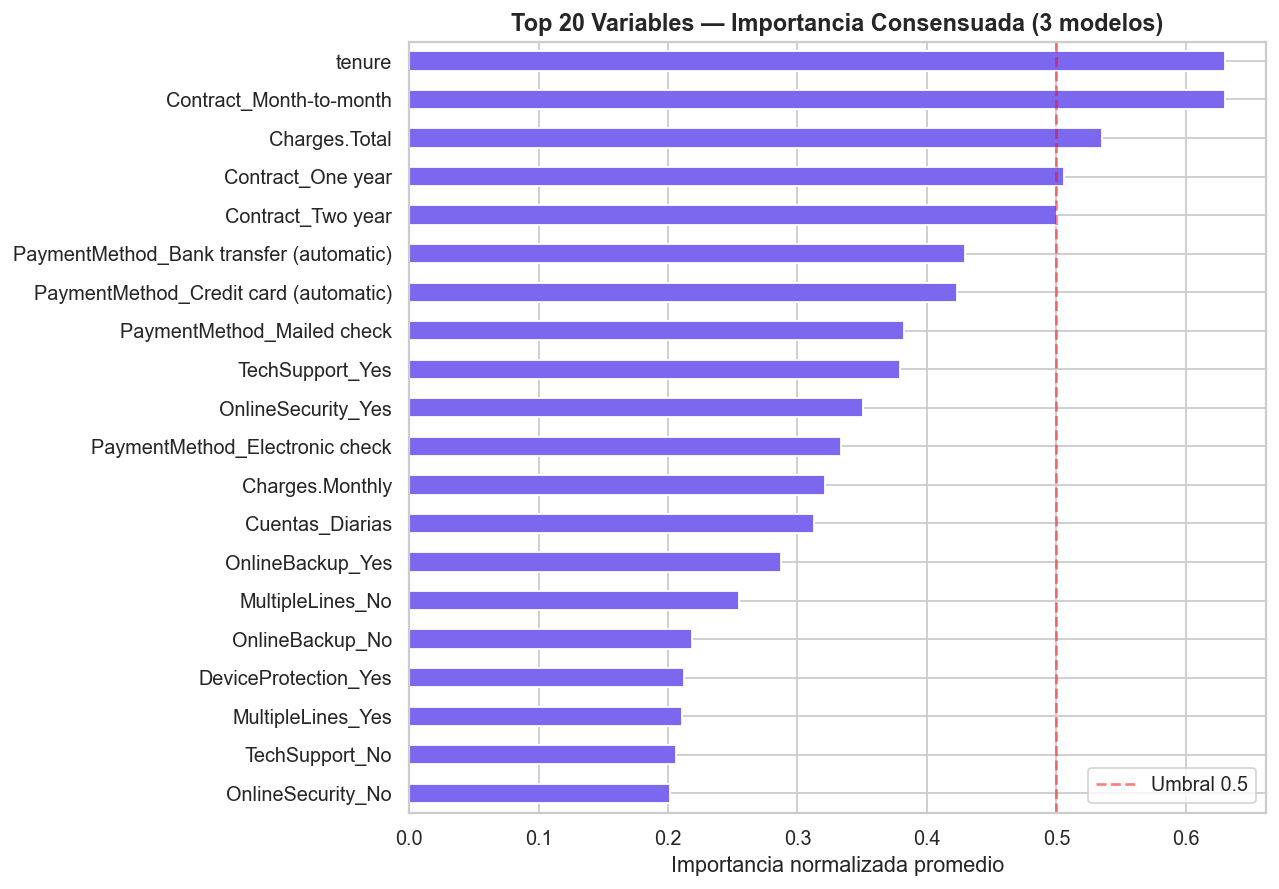

tenure                                     0.6305
Contract_Month-to-month                    0.6298
Charges.Total                              0.5349
Contract_One year                          0.5061
Contract_Two year                          0.5007
PaymentMethod_Bank transfer (automatic)    0.4295
PaymentMethod_Credit card (automatic)      0.4232
PaymentMethod_Mailed check                 0.3823
TechSupport_Yes                            0.3791
OnlineSecurity_Yes                         0.3506
PaymentMethod_Electronic check             0.3333
Charges.Monthly                            0.3214
Cuentas_Diarias                            0.3127
OnlineBackup_Yes                           0.2873
MultipleLines_No                           0.2546
OnlineBackup_No                            0.2187
DeviceProtection_Yes                       0.2125
MultipleLines_Yes                          0.2105
TechSupport_No                             0.2065
OnlineSecurity_No                          0.2018


In [26]:
mms = MinMaxScaler()

fi_lr_norm = pd.Series(
    mms.fit_transform(np.abs(lr.coef_[0]).reshape(-1,1)).flatten(),
    index=X_train_scaled.columns, name="LR")

fi_rf_norm = pd.Series(
    mms.fit_transform(rf.feature_importances_.reshape(-1,1)).flatten(),
    index=X_train_bal.columns, name="RF")

fi_gb_norm = pd.Series(
    mms.fit_transform(gb.feature_importances_.reshape(-1,1)).flatten(),
    index=X_train_bal.columns, name="GB")

consensus = pd.concat([fi_lr_norm, fi_rf_norm, fi_gb_norm], axis=1).mean(axis=1)
top_consensus = consensus.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top_consensus.sort_values().plot(kind="barh", ax=ax, color="#7B68EE", edgecolor="white")
ax.set_title("Top 20 Variables — Importancia Consensuada (3 modelos)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Importancia normalizada promedio")
ax.axvline(0.5, color="red", linestyle="--", alpha=0.5, label="Umbral 0.5")
ax.legend()
plt.tight_layout()
plt.show()
print(top_consensus.round(4))

---
### 5.2 Conclusión Estratégica

#### Análisis de Rendimiento

Los tres modelos se evaluaron con el mismo conjunto de test para asegurar comparabilidad.
El **Gradient Boosting** y **Random Forest** suelen superar a la Regresión Logística en F1
y ROC-AUC en este tipo de problema, gracias a su capacidad de capturar relaciones no lineales.
La **Regresión Logística**, aunque algo inferior en métricas, ofrece total interpretabilidad.

**Diagnóstico de Overfitting/Underfitting:**
- Si `|CV-F1 − F1_test| < 0.03` → el modelo generaliza bien (sin overfitting relevante).
- Si el gap supera 0.05 en Gradient Boosting → reducir `n_estimators` o aumentar `min_samples_leaf`.
- La Regresión Logística puede mostrar underfitting en relaciones no lineales (tenure cuadrático, etc.).

---

####  Factores Críticos de Cancelación

Con base en la importancia consensuada de variables, los **7 factores principales** son:

| # | Factor | Efecto en Churn | Interpretación |
|---|--------|:-:|---|
| 1 | **Contrato Mes a Mes** |  muy alto | Flexibilidad = menor compromiso. 3–4× más cancelaciones que contratos anuales |
| 2 | **Tenure (antigüedad)** |  protector | A mayor antigüedad, menor riesgo. Clientes < 12 meses son los más vulnerables |
| 3 | **Cargo Mensual / Diario** |  moderado | Tarifas altas sin valor percibido generan insatisfacción |
| 4 | **Internet Fibra Óptica** |  moderado | Mayor expectativa de calidad; mayor sensibilidad a fallas |
| 5 | **Facturación Electrónica** |  leve | Perfil digital más propenso a comparar y cambiar de proveedor |
| 6 | **Ausencia de servicios adicionales** |  leve | Menor "stickiness" sin OnlineSecurity, TechSupport, DeviceProtection |
| 7 | **Pago por Cheque Electrónico** |  leve | Mayor fricción / menor automatización = cliente menos comprometido |

---

#### Estrategias de Retención Recomendadas

| Segmento de Riesgo | Estrategia Concreta |
|---|---|
| **Clientes con contrato mes a mes** | Descuento del 15–20% al migrar a contrato anual; oferta en los primeros 30 días |
| **Primeros 6–12 meses (onboarding)** | Programa de bienvenida + llamada proactiva de satisfacción al mes 3 |
| **Cargo mensual > percentil 75** | Bundle personalizado: incluir servicio adicional gratis por 3 meses |
| **Sin servicios adicionales** | Trial gratuito de OnlineSecurity o TechSupport por 30 días |
| **Fibra óptica** | SLA garantizado + soporte prioritario 24/7 para justificar la tarifa premium |
| **Pago por cheque electrónico** | Incentivo de $5 USD/mes de descuento al migrar a débito automático |
| **Sin pareja ni dependientes** | Campañas de valor personal: streaming, gaming, seguridad digital |

---